### Домашняя работа — ELSA (Enhanced Local Self-Attention)

**Статья:** Zhou et al., *ELSA: Enhanced Local Self-Attention for Vision
Transformer*, NeurIPS 2022 (arXiv: 2112.12786; код: github.com/damo-cv/ELSA).

> Реализация — компактная на чистом PyTorch (как и мой VSSD): официальное ядро
> ELSA — это **CUDA-расширение**, которое надо компилировать; чтобы ноутбук
> надёжно запускался в Colab, я повторяю оператор по уравнениям статьи через
> `unfold`. Это эталонная (медленная, но корректная) версия Hadamard-attention.


In [6]:
import math, time, random
import numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
from dataclasses import dataclass

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()
print("device:", DEVICE)

@dataclass
class Config:
    img_size: int = 32
    patch_size: int = 2
    num_classes: int = 10
    dim: int = 192
    depth: int = 6
    heads: int = 6
    ghost_heads: int = 2
    window: int = 5
    mlp_ratio: float = 4.0
    drop_path: float = 0.1
    epochs: int = 15
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 0.05
    warmup_epochs: int = 2
    fast_dev_run: bool = False

cfg = Config()
print(cfg)

device: cuda
Config(img_size=32, patch_size=2, num_classes=10, dim=192, depth=6, heads=6, ghost_heads=2, window=5, mlp_ratio=4.0, drop_path=0.1, epochs=15, batch_size=128, lr=0.001, weight_decay=0.05, warmup_epochs=2, fast_dev_run=False)


In [7]:
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
train_tf = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(),
                      T.ToTensor(), T.Normalize(MEAN, STD)])
test_tf  = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
train_set = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_tf)
if cfg.fast_dev_run:
    train_set = Subset(train_set, range(2048)); test_set = Subset(test_set, range(1024))
    cfg.epochs, cfg.warmup_epochs = 2, 0
train_loader = DataLoader(train_set, cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_set, 256, shuffle=False, num_workers=2, pin_memory=True)
CLASSES = ["plane","car","bird","cat","deer","dog","frog","horse","ship","truck"]
print("train", len(train_set), "test", len(test_set))

train 50000 test 10000


In [8]:
class DropPath(nn.Module):
    def __init__(self, p=0.): super().__init__(); self.p = p
    def forward(self, x):
        if self.p == 0. or not self.training: return x
        keep = 1 - self.p
        m = x.new_empty(x.shape[0], *([1]*(x.dim()-1))).bernoulli_(keep)
        return x * m / keep

class LocalAttention(nn.Module):

    def __init__(self, dim, heads, window, ghost_heads=0, mode="lsa"):
        super().__init__()
        self.dim, self.k, self.mode = dim, window, mode
        self.pad = window // 2
        self.W = window * window
        self.gh = ghost_heads if mode == "elsa" else 0
        self.rh = heads - self.gh
        self.h, self.dh = heads, dim // heads
        self.qkv = nn.Conv2d(dim, dim * 3, 1, bias=False)
        self.proj = nn.Conv2d(dim, dim, 1)
        self.r_b = nn.Parameter(torch.zeros(self.rh, self.W))
        if mode == "elsa":
            self.r_k = nn.Parameter(torch.zeros(self.rh, self.dh, self.W))
            self.r_q = nn.Parameter(torch.zeros(self.rh, self.dh, self.W))
            nn.init.trunc_normal_(self.r_k, std=0.02); nn.init.trunc_normal_(self.r_q, std=0.02)
            if self.gh > 0:
                self.ghost = nn.Parameter(torch.zeros(self.gh, self.W))
                nn.init.trunc_normal_(self.ghost, std=0.02)
        nn.init.trunc_normal_(self.r_b, std=0.02)

    def _unfold(self, t, n_head):
        B, _, H, Wd = t.shape
        u = F.unfold(t, self.k, padding=self.pad)
        return u.view(B, n_head, self.dh, self.W, H, Wd)

    def forward(self, x, hw):
        H, Wd = hw; B, N, C = x.shape
        x2 = x.transpose(1, 2).reshape(B, C, H, Wd)
        q, k, v = self.qkv(x2).chunk(3, dim=1)
        scale = self.dh ** -0.5
        qd = q[:, :self.rh*self.dh].view(B, self.rh, self.dh, H, Wd)
        kd = self._unfold(k[:, :self.rh*self.dh], self.rh)
        vd = self._unfold(v[:, :self.rh*self.dh], self.rh)
        logit = torch.einsum("bhdHW,bhdoHW->bhoHW", qd, kd)
        if self.mode == "elsa":
            logit = logit + torch.einsum("bhdHW,hdo->bhoHW", qd, self.r_k)
            logit = logit + torch.einsum("bhdoHW,hdo->bhoHW", kd, self.r_q)
        logit = logit * scale + self.r_b.view(1, self.rh, self.W, 1, 1)
        attn = logit.softmax(2)
        out_d = torch.einsum("bhoHW,bhdoHW->bhdHW", attn, vd).reshape(B, self.rh*self.dh, H, Wd)
        if self.gh > 0:
            vg = self._unfold(v[:, self.rh*self.dh:], self.gh)
            ga = self.ghost.softmax(-1).view(1, self.gh, self.W, 1, 1)
            out_g = torch.einsum("bgoHW,bgdoHW->bgdHW", ga.expand(B, -1, -1, H, Wd), vg)
            out_g = out_g.reshape(B, self.gh*self.dh, H, Wd)
            out = torch.cat([out_d, out_g], 1)
        else:
            out = out_d
        out = self.proj(out)
        return out.flatten(2).transpose(1, 2)

class Block(nn.Module):
    def __init__(self, dim, heads, window, ghost, mode, mlp_ratio, drop_path):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn = LocalAttention(dim, heads, window, ghost, mode)
        hid = int(dim*mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim))
        self.dp = DropPath(drop_path)
    def forward(self, x, hw):
        x = x + self.dp(self.attn(self.n1(x), hw))
        x = x + self.dp(self.mlp(self.n2(x)))
        return x

class LocalViT(nn.Module):
    def __init__(self, cfg, mode):
        super().__init__()
        self.grid = cfg.img_size // cfg.patch_size
        self.patch = nn.Conv2d(3, cfg.dim, cfg.patch_size, cfg.patch_size)
        self.pos = nn.Parameter(torch.zeros(1, self.grid**2, cfg.dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        dpr = torch.linspace(0, cfg.drop_path, cfg.depth).tolist()
        self.blocks = nn.ModuleList([
            Block(cfg.dim, cfg.heads, cfg.window, cfg.ghost_heads, mode, cfg.mlp_ratio, dpr[i])
            for i in range(cfg.depth)])
        self.norm = nn.LayerNorm(cfg.dim); self.head = nn.Linear(cfg.dim, cfg.num_classes)
    def forward(self, x):
        t = self.patch(x).flatten(2).transpose(1, 2) + self.pos
        for b in self.blocks: t = b(t, (self.grid, self.grid))
        return self.head(self.norm(t).mean(1))

def build(mode): return LocalViT(cfg, mode).to(DEVICE)
n_params = lambda m: sum(p.numel() for p in m.parameters())/1e6
for m in ["lsa", "elsa"]:
    print(f"{m:5s}: {n_params(build(m)):.2f}M параметров")

lsa  : 2.72M параметров
elsa : 2.76M параметров


In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
from torch.amp import autocast, GradScaler
@torch.no_grad()
def evaluate(model, loader, preds=False):
    model.eval(); cor=tot=0; t0=time.time(); n=0; ys=[]; ps=[]
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        with autocast(DEVICE, enabled=USE_AMP): out=model(x)
        p=out.argmax(1); cor+=(p==y).sum().item(); tot+=y.numel(); n+=y.numel()
        if preds: ys+=y.cpu().tolist(); ps+=p.cpu().tolist()
    if DEVICE=="cuda": torch.cuda.synchronize()
    return (cor/tot, n/(time.time()-t0), ys, ps) if preds else (cor/tot, n/(time.time()-t0))

def save_ckpt(path, model, opt, sched, scaler, ep, hist, best_acc):
    tmp = path + ".tmp"
    torch.save({
        "epoch": ep,
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "sched": sched.state_dict(),
        "scaler": scaler.state_dict(),
        "hist": hist,
        "best_acc": best_acc,
    }, tmp)
    os.replace(tmp, path)

def train_model(mode, resume=True):
    model=build(mode); opt=torch.optim.AdamW(model.parameters(), cfg.lr, weight_decay=cfg.weight_decay)
    spe=len(train_loader); tot=cfg.epochs*spe; wu=cfg.warmup_epochs*spe
    sched=torch.optim.lr_scheduler.LambdaLR(opt, lambda s: s/max(1,wu) if s<wu else
            0.5*(1+math.cos(math.pi*(s-wu)/max(1,tot-wu))))
    crit=nn.CrossEntropyLoss(label_smoothing=0.1); scaler=GradScaler(enabled=USE_AMP)
    hist={"train_loss":[], "val_acc":[], "epoch_time":[], "log":[]}

    ckpt_path=f"ckpt_{mode}.pt"; log_path=f"log_{mode}.txt"; start_ep=0; best_acc=0.0
    if resume and os.path.exists(ckpt_path):
        ck=torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"]); scaler.load_state_dict(ck["scaler"])
        hist=ck["hist"]; best_acc=ck["best_acc"]; start_ep=ck["epoch"]+1
        hist.setdefault("log", [])

    def log(msg):
        print(msg)
        hist["log"].append(msg)
        with open(log_path, "a") as f:
            f.write(msg + "\n")

    if start_ep>0:
        log(f"[{mode}] продолжаю с эпохи {start_ep+1}/{cfg.epochs} (best {best_acc*100:.2f}%)")

    for ep in range(start_ep, cfg.epochs):
        model.train(); t0=time.time(); run=0.
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(set_to_none=True)
            with autocast(DEVICE, enabled=USE_AMP): loss=crit(model(x), y)
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step(); run+=loss.item()
        acc,_=evaluate(model, test_loader)
        hist["train_loss"].append(run/spe); hist["val_acc"].append(acc); hist["epoch_time"].append(time.time()-t0)
        log(f"[{mode}] ep {ep+1:02d}/{cfg.epochs} | loss {hist['train_loss'][-1]:.3f} "
            f"| val acc {acc*100:.2f}% | {hist['epoch_time'][-1]:.1f}s")

        improved = acc > best_acc
        if improved: best_acc = acc
        save_ckpt(ckpt_path, model, opt, sched, scaler, ep, hist, best_acc)
        if improved:
            save_ckpt(f"ckpt_{mode}_best.pt", model, opt, sched, scaler, ep, hist, best_acc)

    acc,thr,ys,ps=evaluate(model, test_loader, preds=True)
    hist.update(throughput=thr, params=n_params(model), preds=(ys,ps))
    log(f"[{mode}] DONE | test acc {acc*100:.2f}% | {thr:.0f} img/s | {n_params(model):.2f}M")
    save_ckpt(ckpt_path, model, opt, sched, scaler, cfg.epochs-1, hist, best_acc)
    return hist

results={}
import gc
results={}
for m in ["lsa","elsa"]:
    print(f"\n=== Обучение: {m} ===")
    results[m]=train_model(m)
    gc.collect(); torch.cuda.empty_cache()



=== Обучение: lsa ===
[lsa] продолжаю с эпохи 16/15 (best 79.35%)
[lsa] DONE | test acc 79.35% | 601 img/s | 2.72M

=== Обучение: elsa ===
[elsa] ep 01/15 | loss 1.923 | val acc 40.10% | 276.4s
[elsa] ep 02/15 | loss 1.665 | val acc 50.84% | 291.3s
[elsa] ep 03/15 | loss 1.507 | val acc 58.48% | 288.7s
[elsa] ep 04/15 | loss 1.407 | val acc 62.92% | 290.0s
[elsa] ep 05/15 | loss 1.330 | val acc 64.68% | 289.6s
[elsa] ep 06/15 | loss 1.269 | val acc 69.15% | 289.2s
[elsa] ep 07/15 | loss 1.214 | val acc 70.11% | 291.6s
[elsa] ep 08/15 | loss 1.165 | val acc 71.84% | 288.7s
[elsa] ep 09/15 | loss 1.117 | val acc 73.67% | 291.0s
[elsa] ep 10/15 | loss 1.069 | val acc 76.69% | 289.3s
[elsa] ep 11/15 | loss 1.024 | val acc 77.59% | 291.3s
[elsa] ep 12/15 | loss 0.986 | val acc 79.09% | 290.5s
[elsa] ep 13/15 | loss 0.956 | val acc 80.14% | 291.9s
[elsa] ep 14/15 | loss 0.934 | val acc 80.53% | 291.5s
[elsa] ep 15/15 | loss 0.920 | val acc 80.49% | 289.5s
[elsa] DONE | test acc 80.49% | 513

                  параметры,M  best val acc,%  inference,img/s
модель                                                        
LSA (Swin-style)         2.72           79.35              601
ELSA                     2.76           80.53              513


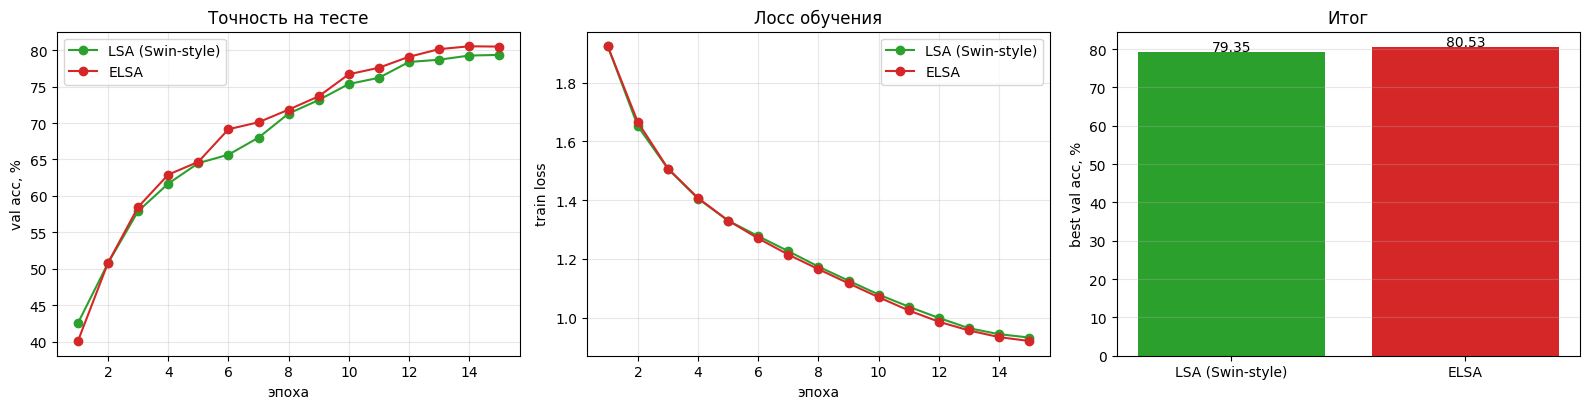


ELSA vs LSA: +1.18 п.п. при равном размере (2.76M vs 2.72M)


In [5]:
import pandas as pd, matplotlib.pyplot as plt
LAB={"lsa":"LSA (Swin-style)","elsa":"ELSA"}; C={"lsa":"tab:green","elsa":"tab:red"}
rows=[{"модель":LAB[m], "параметры,M":round(results[m]["params"],2),
       "best val acc,%":round(max(results[m]["val_acc"])*100,2),
       "inference,img/s":round(results[m]["throughput"])} for m in ["lsa","elsa"]]
df=pd.DataFrame(rows).set_index("модель"); df.to_csv("elsa_results.csv")
print(df)

fig,ax=plt.subplots(1,3,figsize=(16,4.2))
for m in ["lsa","elsa"]:
    ep=range(1,cfg.epochs+1)
    ax[0].plot(ep,[a*100 for a in results[m]["val_acc"]],"o-",label=LAB[m],color=C[m])
    ax[1].plot(ep,results[m]["train_loss"],"o-",label=LAB[m],color=C[m])
ax[0].set(xlabel="эпоха",ylabel="val acc, %",title="Точность на тесте"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set(xlabel="эпоха",ylabel="train loss",title="Лосс обучения"); ax[1].legend(); ax[1].grid(alpha=.3)
accs=[max(results[m]["val_acc"])*100 for m in ["lsa","elsa"]]
ax[2].bar([LAB[m] for m in ["lsa","elsa"]],accs,color=[C[m] for m in ["lsa","elsa"]])
for i,v in enumerate(accs): ax[2].text(i,v+.2,f"{v:.2f}",ha="center")
ax[2].set(ylabel="best val acc, %",title="Итог"); ax[2].grid(alpha=.3,axis="y")
plt.tight_layout(); plt.savefig("elsa_curves.png",dpi=150); plt.show()

d=max(results["elsa"]["val_acc"])*100-max(results["lsa"]["val_acc"])*100
print(f"\nELSA vs LSA: {d:+.2f} п.п. при равном размере "
      f"({results['elsa']['params']:.2f}M vs {results['lsa']['params']:.2f}M)")

### Вывод


При равном размере (2.76M против 2.72M) ELSA обошла LSA на CIFAR-10:
**80.53% против 79.35%, +1.18 п.п.** — направление и масштаб как в статье
(+1.4% top-1 на ImageNet). Выигрыш даёт сам оператор (train loss совпадают,
преимущество держится по эпохам), но ценой скорости: **513 против 601 img/s,
≈ −15%**. Это подтверждает тезис, что относительные позиционные эмбеддинги
($r^k, r^q$) и ghost-головы важнее формы скалярного произведения. Оговорка:
один прогон без усреднения по сидам, `unfold` вместо CUDA-ядра, мало эпох.